# El satélite cuenta camiones

Sentinel-2 no saca una foto: barre. Cada banda del instrumento mira el suelo un instante
después que la anterior. El azul (B02) primero, el verde (B03) 0,527 segundos después, el
rojo (B04) 0,478 segundos más tarde. Para una casa no importa. Para un camión a 80 km/h sí:
en ese segundo recorre 22 metros, dos píxeles de 10 m, y queda en la imagen como una mancha
azul, una verde y una roja corridas en el sentido de marcha. Un arcoíris chiquito sobre el
asfalto.

Este notebook usa ese defecto como instrumento. Endereza una ruta a partir del eje del IGN,
busca los arcoíris, les mide el corrimiento (que da la velocidad) y el signo (que da el
sentido), y cuenta. Después hace lo mismo en todas las pasadas de días hábiles desde 2017
sobre la ruta de la arena, la RN 152 en La Pampa, y en tres rutas más para comparar con los
conteos de Vialidad.

No es un conteo completo: el satélite ve una muestra de los vehículos, los que contrastan
con la ruta y van rápido. Lo que sirve es la comparación, entre rutas y entre años, con el
mismo método.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, pandas as pd
from IPython.display import Image, display
from slab import RUTAS, DATA_PROC, FIGURES, LAG_B02_B03, LAG_B03_B04, LAG_B02_B04
from slab.roads import fetch_routes, route_line, along, tmda_2016_near
from slab.scenes import catalog, search, weekdays, scene_crs_bounds, strip, valid_km
from slab.detect import detect, anomalies, VELOCIDAD
from slab.counts import density, daily_from_density, series, by_period
from slab.figures import strip_figure, rainbow_figure, series_figure, routes_figure
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
FIGURES.mkdir(parents=True, exist_ok=True)
routes = fetch_routes(tuple(RUTAS))
print("desfase azul→verde", LAG_B02_B03, "s; verde→rojo", LAG_B03_B04, "s; azul→rojo", LAG_B02_B04, "s")
print("velocidad por corrimiento (km/h):", VELOCIDAD)

desfase azul→verde 0.527 s; verde→rojo 0.478 s; azul→rojo 1.005 s
velocidad por corrimiento (km/h): {1: 36, 2: 72, 3: 107, 4: 143}


## 1. Una pasada sobre la ruta de la arena

La RN 152 al sur de Puelches, La Pampa, un martes de septiembre de 2026 a las 11:33 hora
local, sin nubes. Se toma el tramo de 10 km donde el detector encontró el vehículo más
claro y se muestra la ruta enderezada: arriba en color real, abajo la anomalía de cada
banda respecto del fondo de la propia ruta (azul B02, verde B03, rojo B04). Un vehículo en
movimiento es una secuencia azul, verde, roja; un objeto fijo es blanco, porque es anómalo
en las tres bandas en el mismo lugar.

In [2]:
ESCENA = "S2B_19HGT_20260908_0_L2A"
cfg = RUTAS["152"]
item = next(catalog().search(collections=["sentinel-2-l2a"], ids=[ESCENA]).items())
crs, bounds = scene_crs_bounds(item)
line = route_line(routes, "152", crs, bounds)
d0 = along(line, cfg["lon"], cfg["lat"], crs)
print(item.id, item.datetime, "nubes", round(item.properties["eo:cloud_cover"], 2), "%; eje de la RN 152 en la escena:", round(line.length / 1000), "km")

# todo el tramo, de a 10 km
tramos, dets = {}, []
for start in np.arange(cfg["km"][0] * 1000, cfg["km"][1] * 1000, 10000):
    a, b = d0 + start, d0 + start + 10000
    if a < 0 or a >= line.length:
        continue
    s = strip(item, line, a, b)
    if valid_km(s) < 1:
        continue
    d = detect(s)
    d["km_tramo"] = start / 1000 + d["along_m"] / 1000
    tramos[start / 1000] = s
    dets.append(d)
det = pd.concat(dets, ignore_index=True)
km_validos = sum(valid_km(s) for s in tramos.values())
print(len(det), "vehículos en movimiento en", round(km_validos, 1), "km válidos")
det[["km_tramo", "sentido", "velocidad_kmh", "signo", "confianza", "z_b", "z_g", "z_r", "corr"]].sort_values("km_tramo").round(2)

S2B_19HGT_20260908_0_L2A 2026-09-08 14:33:21.704000+00:00 nubes 0.06 %; eje de la RN 152 en la escena: 221 km


3 vehículos en movimiento en 65.5 km válidos


,km_tramo,sentido,velocidad_kmh,signo,confianza,z_b,z_g,z_r,corr
0,-54.12,-1,107,1,media,3.34608,2.488579,3.331307,0.963816
1,-30.48,1,107,1,alta,7.042686,5.334937,2.542271,0.780868
2,-14.17,-1,107,1,alta,7.209381,8.468038,7.493678,0.85124


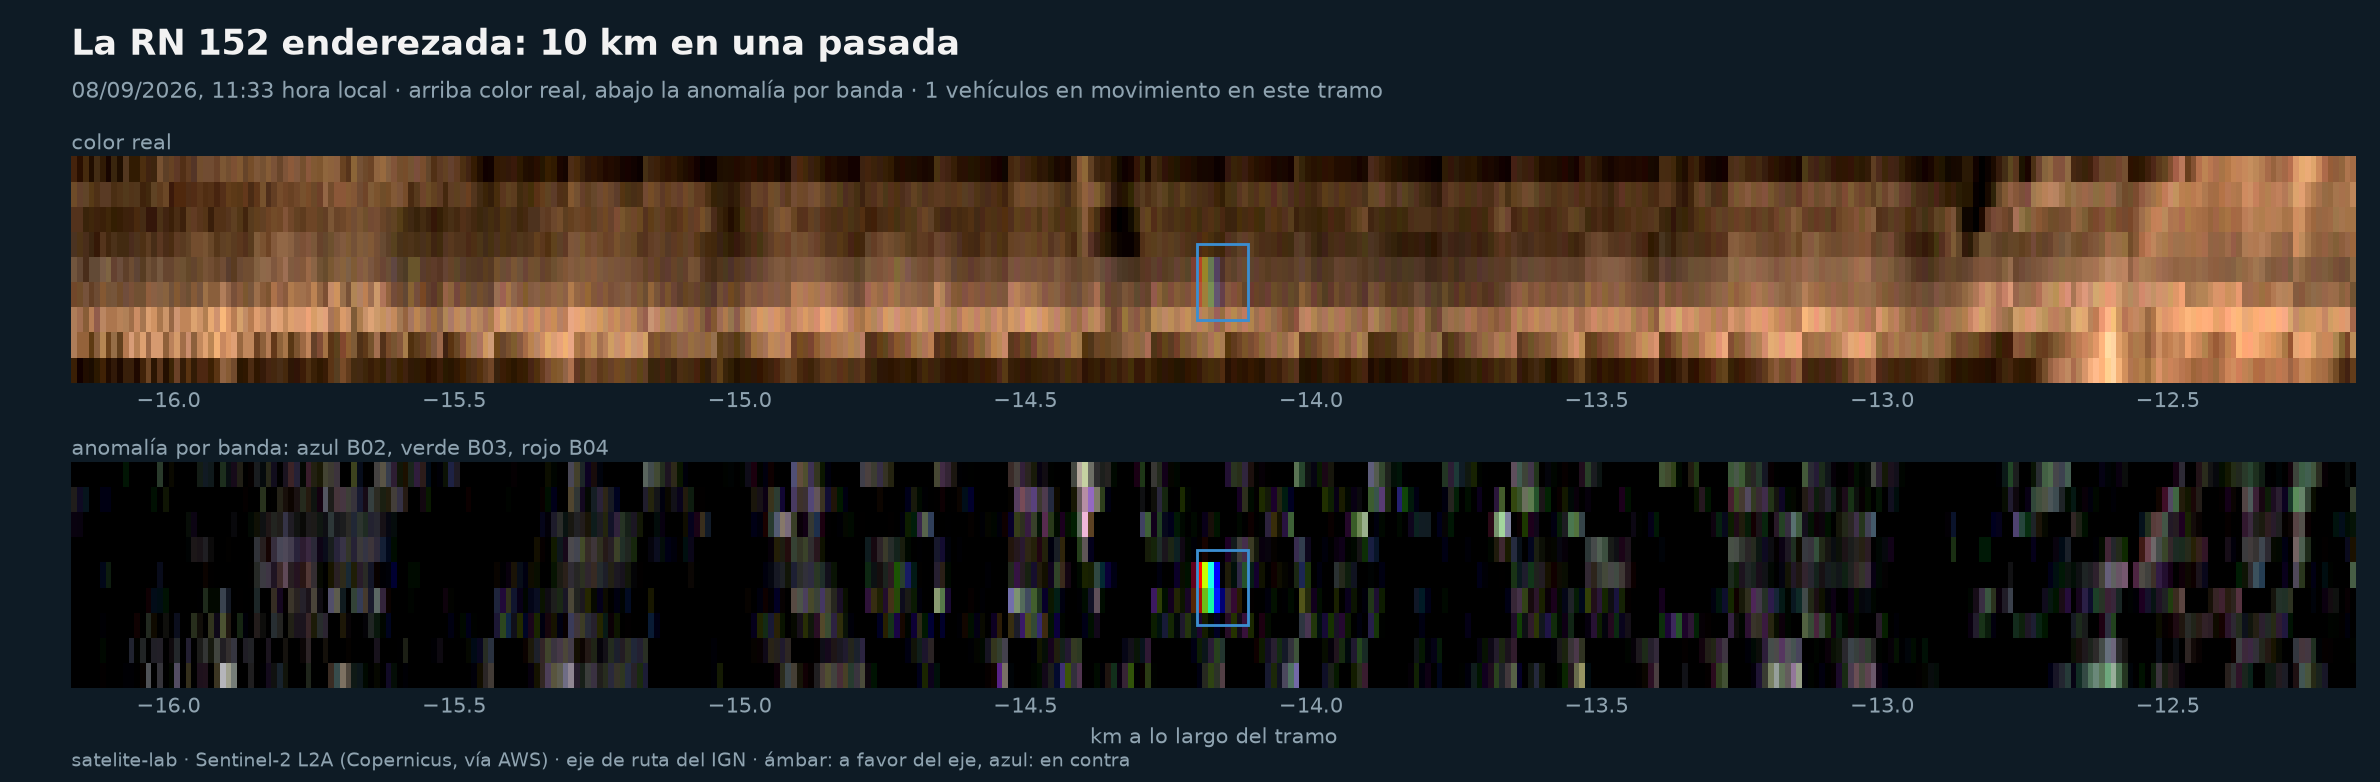

In [3]:
mejor = det.sort_values(["confianza", "score"], ascending=[True, False]).iloc[0]
start = [k for k in tramos if k <= mejor["km_tramo"] < k + 10][0]
s = tramos[start]; z, amp = anomalies(s)
d_tramo = det[(det["km_tramo"] >= start) & (det["km_tramo"] < start + 10)]
strip_figure(s, z, d_tramo, FIGURES / "ruta_enderezada.png", "La RN 152 enderezada: 10 km en una pasada",
             f"{item.datetime:%d/%m/%Y}, 11:33 hora local · arriba color real, abajo la anomalía por banda · {len(d_tramo)} vehículos en movimiento en este tramo",
             km0=start, ventana_km=(max(0, (mejor['km_tramo'] - start) - 2.0), min(10, (mejor['km_tramo'] - start) + 2.0)))
display(Image(str(FIGURES / "ruta_enderezada.png")))

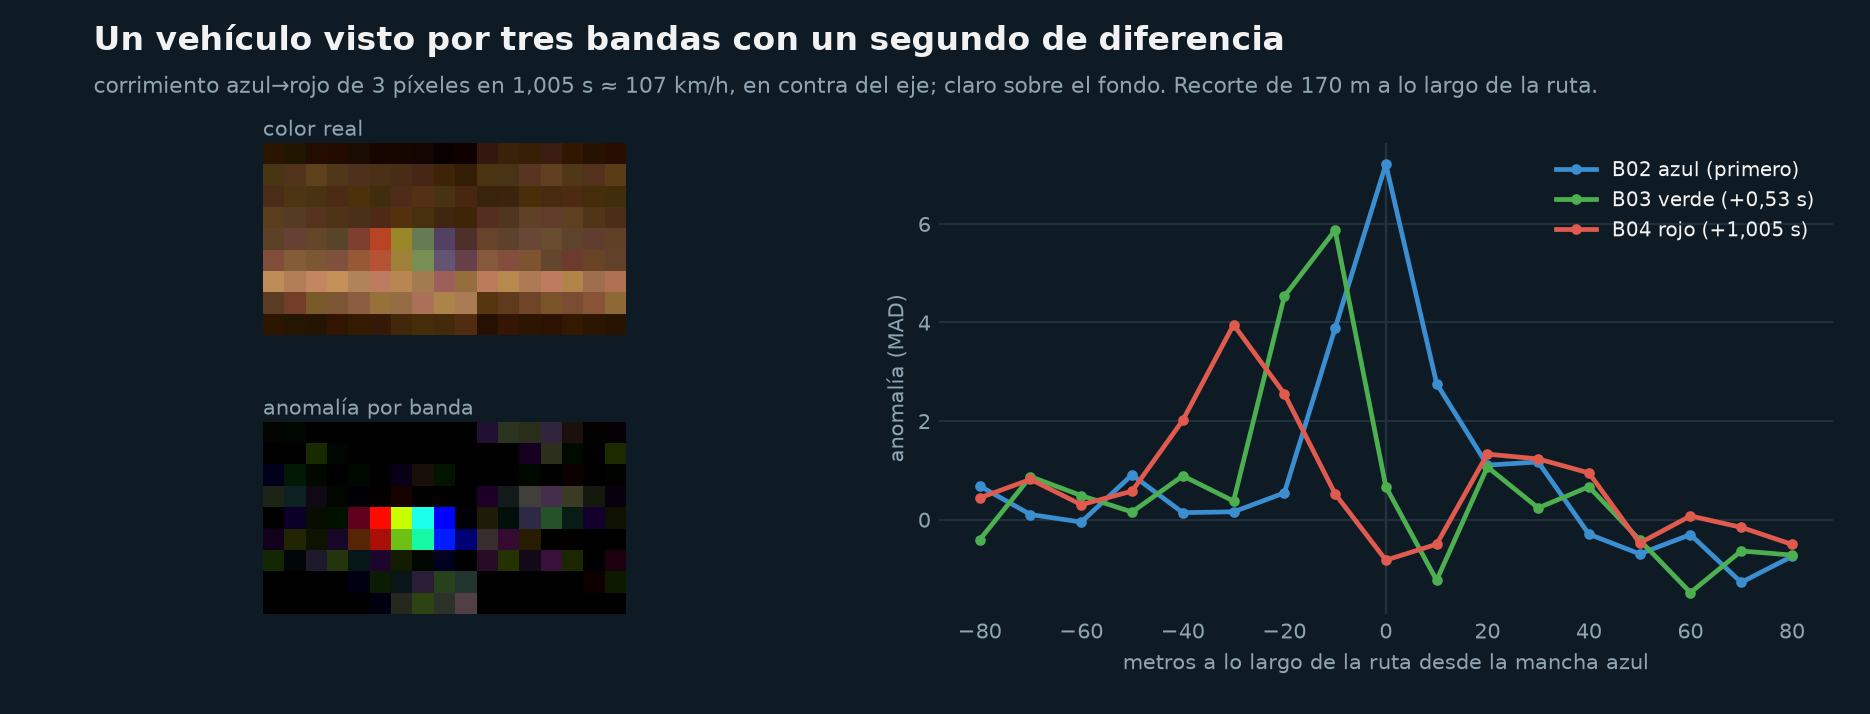

In [4]:
rainbow_figure(s, z, mejor, FIGURES / "arcoiris.png", "Un vehículo visto por tres bandas con un segundo de diferencia",
               zoom_note="Recorte de 170 m a lo largo de la ruta.")
display(Image(str(FIGURES / "arcoiris.png")))

## 2. Cuántos, hacia dónde y a qué velocidad

El corrimiento solo toma valores enteros de píxel, así que la velocidad sale en escalones:
dos píxeles son 72 km/h (entre 54 y 90), tres son 107 (entre 90 y 125). Un camión cargado
va a 80; una camioneta, a 110. El sentido sale del signo: a favor del eje del IGN (que en
este tramo va hacia el suroeste, hacia Casa de Piedra y Neuquén) o en contra.

In [5]:
res = density(det, km_validos)
tabla = det.groupby(["sentido", "velocidad_kmh"]).size().unstack(fill_value=0)
tabla.index = ["en contra (hacia el noreste)" if i < 0 else "a favor (hacia el suroeste)" for i in tabla.index]
print(f"{res['n']} vehículos en {res['km']:.1f} km: {res['por_100km']:.1f} por 100 km; {res['n_alta']} de confianza alta")
print(f"si todos fueran a 80 km/h y el flujo de media mañana fuera el de todo el día: {daily_from_density(res['por_100km']):.0f} vehículos por día (cota gruesa)")
print("Vialidad contó en este tramo en 2016:", tmda_2016_near("152", cfg["lon"], cfg["lat"])["tmda_2016"], "vehículos por día, antes de la arena")
tabla

3 vehículos en 65.5 km: 4.6 por 100 km; 2 de confianza alta
si todos fueran a 80 km/h y el flujo de media mañana fuera el de todo el día: 88 vehículos por día (cota gruesa)


Vialidad contó en este tramo en 2016: 520.0 vehículos por día, antes de la arena


velocidad_kmh,107
en contra (hacia el noreste),2
a favor (hacia el suroeste),1


## 3. La ruta de la arena, 2017 a 2026

La misma cuenta en todas las pasadas de días hábiles con menos de 5 % de nubes, dos por mes,
sobre los mismos 70 km. Cada punto es un año: vehículos en movimiento por 100 km por pasada,
sumando todas las pasadas del año, con el error de conteo. Abajo, la partición por sentido.

La arena de fractura empezó a circular por acá en 2018 y creció hasta 2025 (arena-lab y
vacio-lab estiman entre 900 y 1.300 camiones por día en 2025, contra 520 vehículos por día
que contó Vialidad en 2016). Si el satélite ve una fracción constante de lo que pasa, la
serie tiene que subir.

In [6]:
serie = series(pd.read_csv(DATA_PROC / "serie_152.csv").to_dict("records"))
anual = by_period(serie, "YS", min_km=20)
anual.index = anual.index.year
print(len(serie), "pasadas útiles;", int(serie["n"].sum()), "vehículos en", int(serie["km"].sum()), "km recorridos")
anual[["pasadas", "km", "n", "por_100km", "error_100km", "alta_100km", "pct_pos", "n_lag2", "n_lag3"]].round(1)

213 pasadas útiles; 840 vehículos en 13465 km recorridos


,pasadas,km,n,por_100km,error_100km,alta_100km,pct_pos,n_lag2,n_lag3
fecha,,,,,,,,,
2017,13,838.7,41,4.9,0.8,2.0,56.1,25,16
2018,21,1317.0,70,5.3,0.6,3.8,42.9,47,23
2019,22,1374.9,63,4.6,0.6,3.1,60.3,43,20
2020,25,1618.0,70,4.3,0.5,2.3,55.7,46,24
2021,23,1449.2,67,4.6,0.6,2.0,58.2,49,18
2022,23,1438.9,111,7.7,0.7,4.8,52.3,67,44
2023,22,1372.0,123,9.0,0.8,6.2,52.8,72,51
2024,22,1389.0,102,7.3,0.7,4.2,49.0,64,38
2025,24,1513.0,117,7.7,0.7,4.7,62.4,80,37


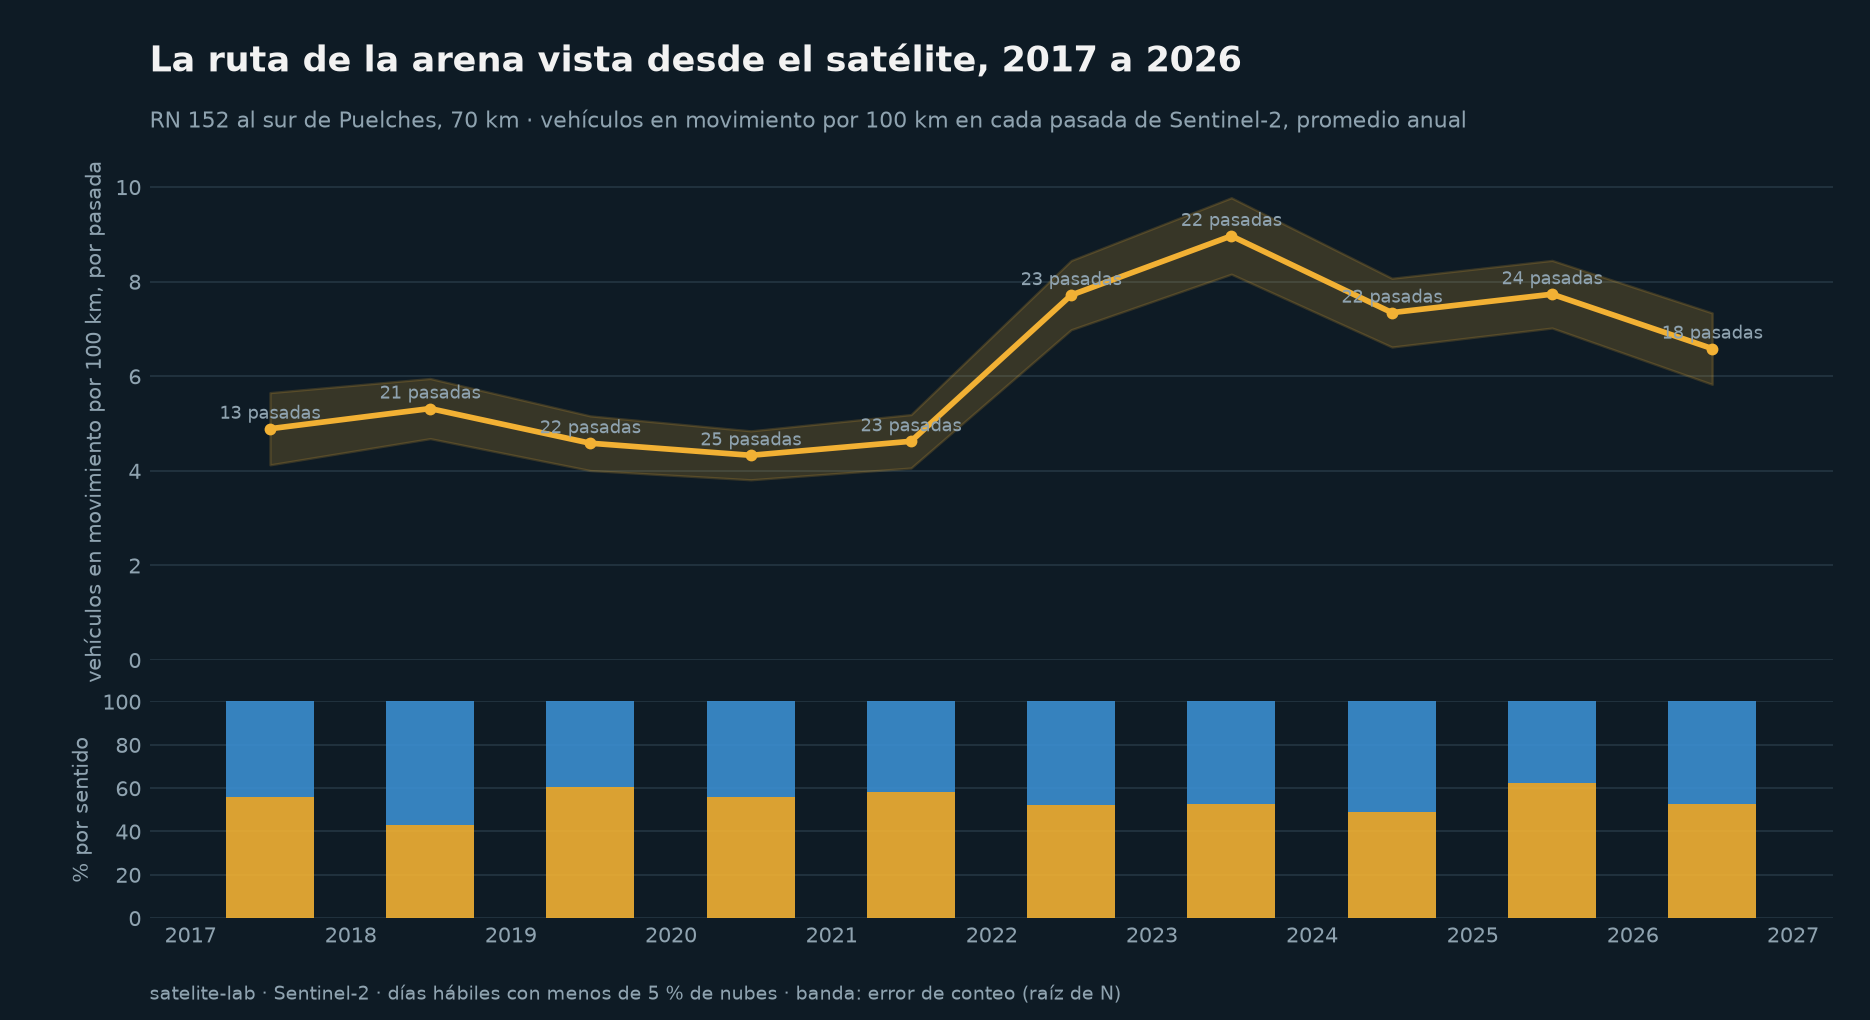

In [7]:
a = anual.copy(); a.index = pd.to_datetime(a.index.astype(str) + "-07-01")
series_figure(a, FIGURES / "serie_rn152.png", "La ruta de la arena vista desde el satélite, 2017 a 2026",
              "RN 152 al sur de Puelches, 70 km · vehículos en movimiento por 100 km en cada pasada de Sentinel-2, promedio anual")
display(Image(str(FIGURES / "serie_rn152.png")))

In [8]:
# lo que dice la serie: el nivel de los últimos años contra el de los primeros
primeros = anual.loc[anual.index <= 2018]; ultimos = anual.loc[anual.index >= 2024]
r0 = primeros["n"].sum() / primeros["km"].sum() * 100; r1 = ultimos["n"].sum() / ultimos["km"].sum() * 100
print(f"2017-2018: {r0:.1f} por 100 km ({int(primeros['pasadas'].sum())} pasadas) · 2024-2026: {r1:.1f} por 100 km ({int(ultimos['pasadas'].sum())} pasadas) · relación {r1 / max(r0, 1e-9):.2f}")
print("reparto por sentido 2024-2026: a favor (hacia Neuquén)", f"{100 * ultimos['n_pos'].sum() / max(ultimos['n'].sum(), 1):.0f} %")

2017-2018: 5.1 por 100 km (34 pasadas) · 2024-2026: 7.3 por 100 km (64 pasadas) · relación 1.41
reparto por sentido 2024-2026: a favor (hacia Neuquén) 55 %


### La arena, año por año

El registro de fractura de la Secretaría de Energía (Adjunto IV) dice cuánta arena se bombeó
cada año en la cuenca Neuquina no convencional, nacional más importada; la serie sale del
mismo cálculo que usa vacio-lab (el año en curso, anualizado). Casi toda esa arena viaja en
camión, y una parte grande de esos camiones pasa por acá. Si el satélite ve una fracción
estable de lo que circula, el índice tiene que seguir a la arena.

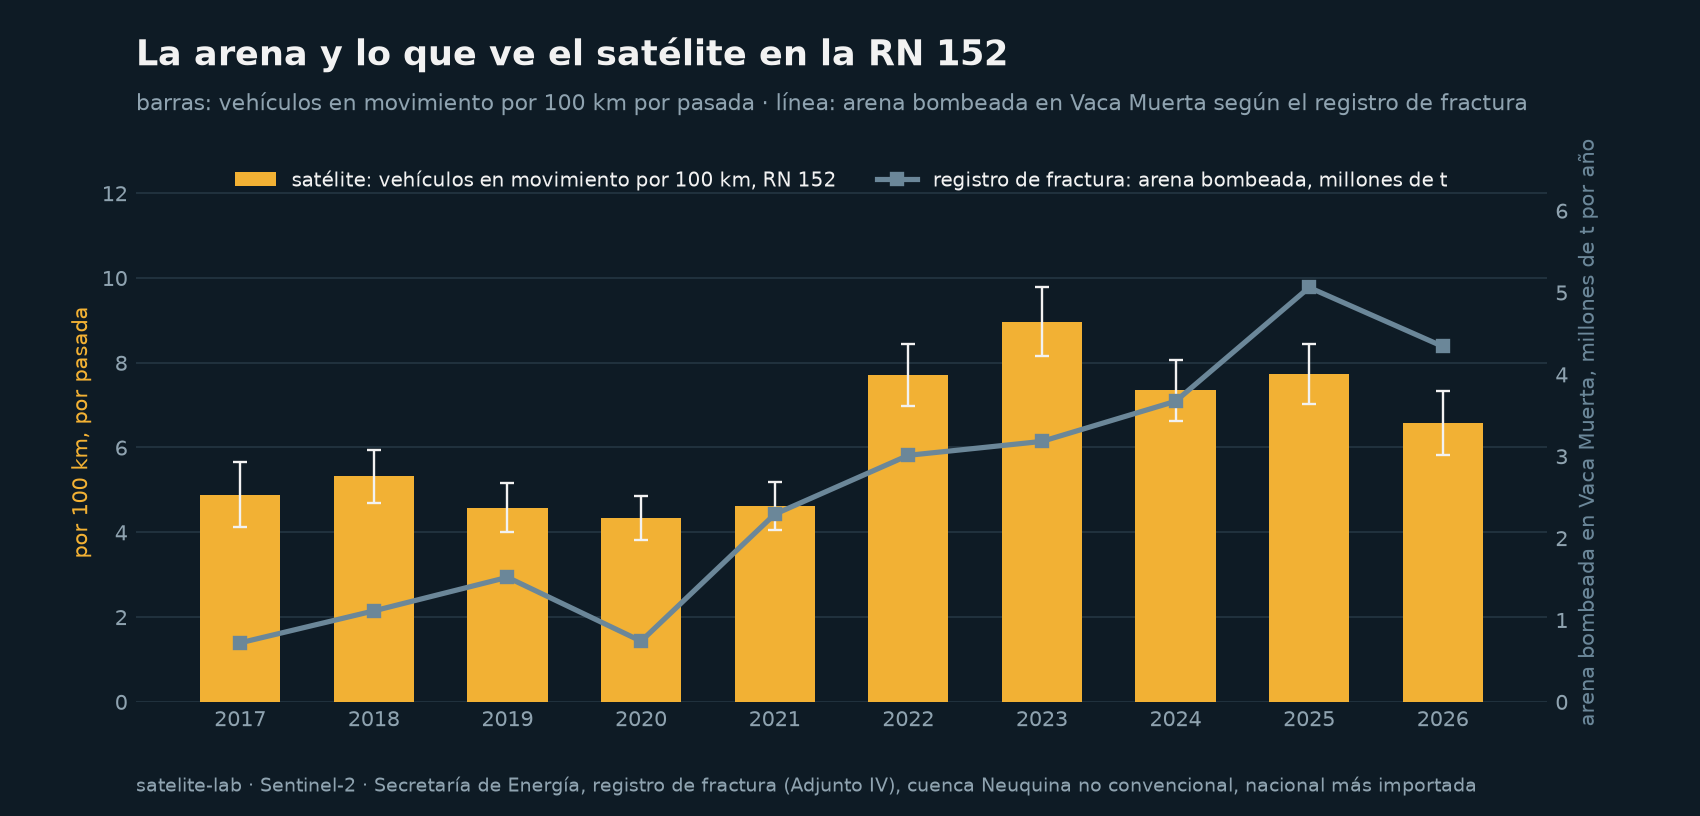

años en común: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
correlación de rangos índice vs arena: 0.72 · Pearson: 0.76


In [9]:
# millones de toneladas por año, registro de fractura (Secretaría de Energía, Adjunto IV), cuenca Neuquina no convencional
ARENA_MT = {2017: 0.72, 2018: 1.11, 2019: 1.52, 2020: 0.74, 2021: 2.29, 2022: 3.01, 2023: 3.18, 2024: 3.67, 2025: 5.06, 2026: 4.34}
from slab.figures import sand_figure
sand_figure(anual, ARENA_MT, FIGURES / "arena_vs_satelite.png", "La arena y lo que ve el satélite en la RN 152",
            "barras: vehículos en movimiento por 100 km por pasada · línea: arena bombeada en Vaca Muerta según el registro de fractura")
display(Image(str(FIGURES / "arena_vs_satelite.png")))
from scipy.stats import spearmanr, pearsonr
comunes = [a for a in anual.index if a in ARENA_MT]
if len(comunes) >= 4:
    print("años en común:", comunes)
    print("correlación de rangos índice vs arena:", round(spearmanr(anual.loc[comunes, "por_100km"], [ARENA_MT[a] for a in comunes]).statistic, 2),
          "· Pearson:", round(pearsonr(anual.loc[comunes, "por_100km"], [ARENA_MT[a] for a in comunes]).statistic, 2))

## 4. Cuatro rutas contra los conteos de Vialidad

Un año de pasadas (septiembre de 2025 a septiembre de 2026, dos por mes) sobre cuatro
rutas distintas: la autopista Rosario-Córdoba (RN 9 en Bell Ville), la RN 33 del grano
(Firmat), la RN 3 patagónica (Garayalde) y la RN 152 de la arena. Al lado, lo que contó
Vialidad en el mismo tramo en 2016, que es el último conteo por tramo publicado. Si el
satélite ve una fracción parecida en todas, el orden tiene que coincidir.

In [10]:
filas = []
for r, c in RUTAS.items():
    p = DATA_PROC / f"serie_{r}.csv"
    if not p.exists():
        continue
    sr = series(pd.read_csv(p).to_dict("records"))
    sr = sr[(sr["fecha"] >= "2025-09-01") & (sr["km"] >= 20)]
    if len(sr) == 0:
        continue
    t = tmda_2016_near(r, c["lon"], c["lat"])
    n, km = sr["n"].sum(), sr["km"].sum()
    filas.append({"ruta": r, "nombre": c["nombre"], "pasadas": len(sr), "km": km, "n": n, "por_100km": 100 * n / km, "error_100km": 100 * np.sqrt(max(n, 1)) / km,
                  "alta_100km": 100 * sr["n_alta"].sum() / km, "pct_pos": 100 * sr["n_pos"].sum() / max(n, 1), "tmda": t["tmda_2016"], "tramo_vialidad": t["tramo"]})
comp = pd.DataFrame(filas).sort_values("tmda", ascending=False).reset_index(drop=True)
comp["veh_por_tmda"] = comp["por_100km"] / comp["tmda"] * 1000
comp.round(2)

,ruta,nombre,pasadas,km,n,por_100km,error_100km,alta_100km,pct_pos,tmda,tramo_vialidad,veh_por_tmda
0,9,"RN 9, Bell Ville (Córdoba)",17,890.74,173,19.42,1.48,9.32,54.91,9000.0,ACC.A LEONES (I) - ACC.A BELL VILLE (I),2.16
1,33,"RN 33, Firmat (Santa Fe)",20,661.15,188,28.44,2.07,16.94,48.94,6850.0,INT.R.P.93 - EMP.R.N.178 (D) (P.SUP.),4.15
2,3,"RN 3, Garayalde (Chubut)",21,1156.15,232,20.07,1.32,15.22,39.66,1803.0,INT.R.P.30 (I) - INT.R.P.37 (D),11.13
3,152,"RN 152, Puelches (La Pampa)",26,1677.73,110,6.56,0.63,4.41,53.64,520.0,INT.R.N.143 (D) (EL CARANCHO) - INT.R.N.232 (I),12.61


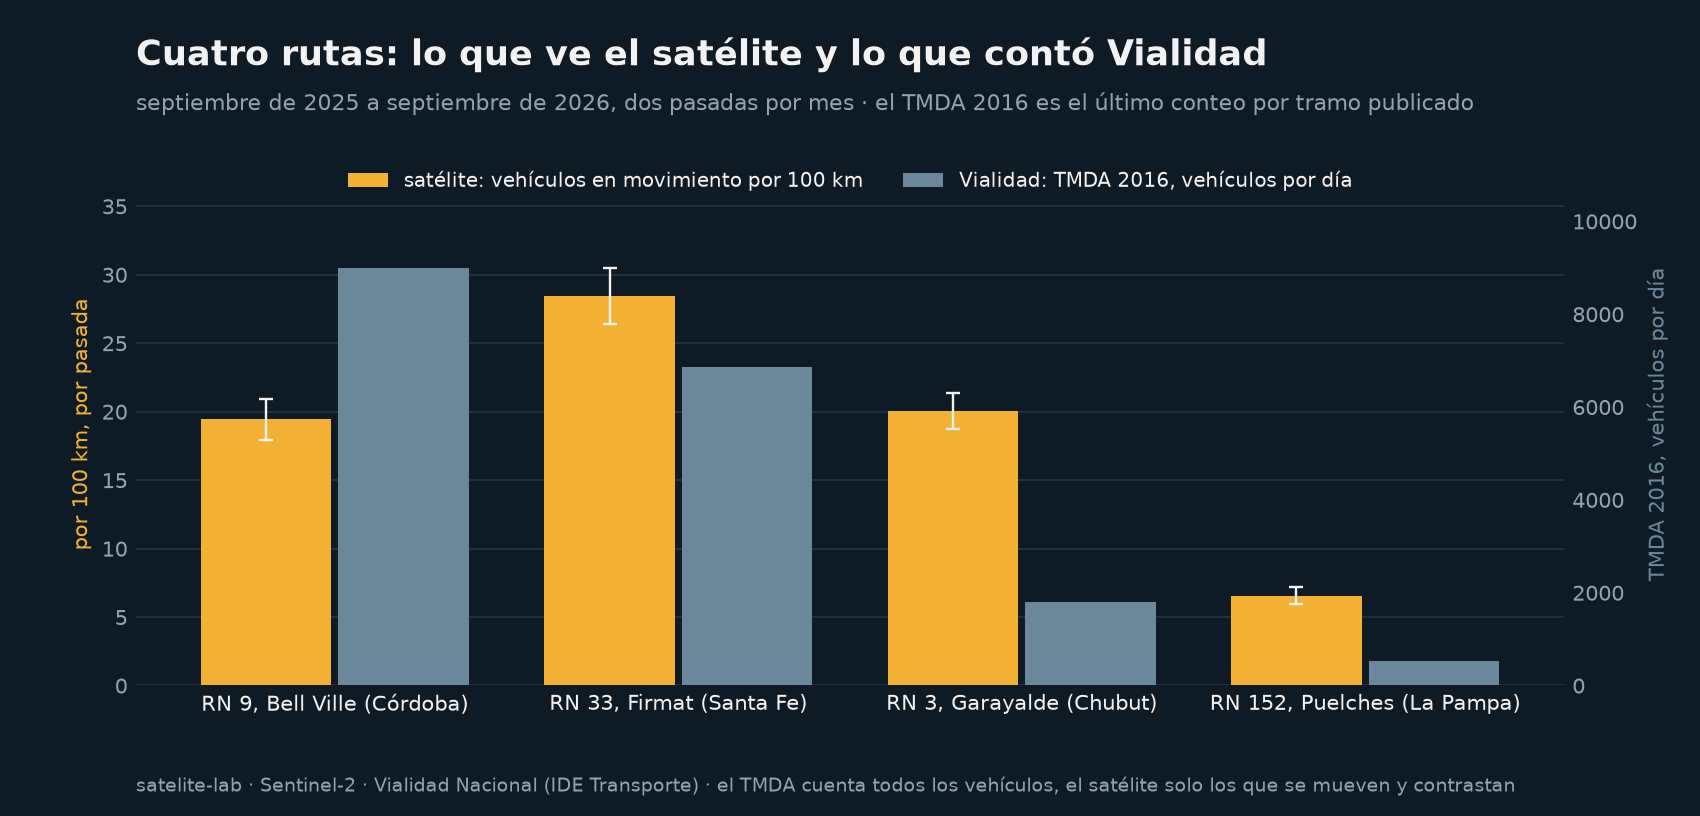

correlación de rangos satélite vs TMDA: 0.4


In [11]:
routes_figure(comp, FIGURES / "rutas_vs_vialidad.png", "Cuatro rutas: lo que ve el satélite y lo que contó Vialidad",
              "septiembre de 2025 a septiembre de 2026, dos pasadas por mes · el TMDA 2016 es el último conteo por tramo publicado")
display(Image(str(FIGURES / "rutas_vs_vialidad.png")))
from scipy.stats import spearmanr
if len(comp) >= 3:
    print("correlación de rangos satélite vs TMDA:", round(spearmanr(comp["por_100km"], comp["tmda"]).statistic, 2))

## 5. Límites

- **El satélite ve una muestra.** Un píxel son 100 m²; un camión ocupa la mitad y un auto
  una décima parte. Solo los vehículos que contrastan con la ruta y van a más de 54 km/h
  dejan un arcoíris limpio. La fracción que se ve no está medida: por eso el índice es
  relativo, y la comparación entre rutas y entre años vale más que el número por día.
- **No distingue camión de auto.** La velocidad ayuda (los camiones van a 80, no a 110)
  y la amplitud de la anomalía también, pero ninguna de las dos alcanza para separar.
- **Es una foto a media mañana.** Todas las pasadas son entre las 10:30 y las 11:30 hora
  local. Pasar de densidad a vehículos por día exige una velocidad y un perfil horario que
  acá se declaran y no se miden.
- **Dos y tres píxeles.** La velocidad sale en escalones de 36 km/h y el sentido depende de
  que el eje del IGN esté bien orientado en cada tramo.
- **Nubes y bordes.** Se usan escenas con menos de 5 % de nubes y la máscara de escena por
  píxel; un tramo tapado no cuenta y el kilometraje válido lo dice.

## 6. Qué sigue

Más pasadas (con tres satélites hay una cada tres días), todas las rutas de vacio-lab, un
conjunto etiquetado a mano para medir la fracción que se ve, y una comparación con
imágenes de 3 m cuando haya acceso a ellas.